<div style="background-color: #1F3864; padding: 20px; border-radius: 5px; margin-bottom: 20px;">
    <h1 style="color: white; margin: 0; font-size: 24px;">10. Baseline Climatology Bias Map</h1>
    <p style="color: #cce0ff; margin: 8px 0 0 0; font-size: 14px;">MPI-GE ensemble-mean vs ERA5 observed JJAS Rx5day climatology (1981-2010) | Figure 9</p>
</div>

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
BASELINE_START, BASELINE_END = 1981, 2010

# MPI-GE gridded anthropogenic Rx5day: dims (member, year, lat, lon)
rx5day_mpi = xr.open_dataarray(OUTPUT_DIR + 'rx5day_jjas_ant_all.nc')

# ERA5 gridded Rx5day: dims (year, latitude, longitude), 1981-2023
rx5day_era5 = xr.open_dataarray(OUTPUT_DIR + 'rx5day_jjas_era5_1981_2023.nc')

print('MPI-GE dims:', dict(rx5day_mpi.sizes))
print('ERA5 dims:', dict(rx5day_era5.sizes))
print('MPI-GE lat range:', float(rx5day_mpi.lat.min()), 'to', float(rx5day_mpi.lat.max()))
print('ERA5 lat range:', float(rx5day_era5.latitude.min()), 'to', float(rx5day_era5.latitude.max()))

MPI-GE dims: {'member': 30, 'year': 165, 'lat': 15, 'lon': 16}
ERA5 dims: {'year': 43, 'latitude': 129, 'longitude': 129}
MPI-GE lat range: 8.393668907692383 to 34.50724334150103
ERA5 lat range: 5.0 to 37.0


In [2]:
# MPI-GE: ensemble-mean, then time-mean, over 1981-2010
mpi_baseline = rx5day_mpi.sel(year=slice(BASELINE_START, BASELINE_END))
mpi_climatology = mpi_baseline.mean(dim=['member', 'year'])

# ERA5: time-mean over 1981-2010 (already single-realization, no ensemble dim)
era5_baseline = rx5day_era5.sel(year=slice(BASELINE_START, BASELINE_END))
era5_climatology = era5_baseline.mean(dim='year')

print(f'MPI-GE climatology: {mpi_climatology.mean().values:.1f} mm mean, shape {dict(mpi_climatology.sizes)}')
print(f'ERA5 climatology: {era5_climatology.mean().values:.1f} mm mean, shape {dict(era5_climatology.sizes)}')

MPI-GE climatology: 122.5 mm mean, shape {'lat': 15, 'lon': 16}
ERA5 climatology: 130.6 mm mean, shape {'latitude': 129, 'longitude': 129}


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 2: Regrid ERA5 to MPI-GE's Grid and Compute Bias</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Interpolates ERA5's finer 0.25° climatology onto MPI-GE's ~1.875° grid, then computes the per-cell bias (MPI-GE minus ERA5).</p>
</div>

In [3]:
# Regrid ERA5 (fine, 0.25deg) DOWN to MPI-GE's grid (coarse, ~1.875deg)
# Standard practice: interpolate the finer product onto the coarser grid,
# not the reverse, to avoid inventing spatial detail MPI-GE doesn't have
era5_climatology_renamed = era5_climatology.rename({'latitude': 'lat', 'longitude': 'lon'})

era5_regridded = era5_climatology_renamed.interp(
    lat=mpi_climatology.lat,
    lon=mpi_climatology.lon,
    method='linear'
)

bias = mpi_climatology - era5_regridded

print(f'ERA5 regridded shape: {dict(era5_regridded.sizes)}')
print(f'Bias (MPI - ERA5) mean: {float(bias.mean()):.1f} mm')
print(f'Bias range: {float(bias.min()):.1f} to {float(bias.max()):.1f} mm')
print(f'Fraction of cells with negative bias (MPI drier): {float((bias < 0).mean())*100:.1f}%')

ERA5 regridded shape: {'lat': 15, 'lon': 16}
Bias (MPI - ERA5) mean: -23.9 mm
Bias range: -369.5 to 151.6 mm
Fraction of cells with negative bias (MPI drier): 56.7%


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 3: Region Outlines for Overlay</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Rebuilds the four study-region outlines from GADM state boundaries, for overlay on Figure 9's climatology and bias panels.</p>
</div>

In [8]:
path = "/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/gadm/gadm41_IND.gpkg"
gdf = gpd.read_file(path, layer="ADM_ADM_1")
gdf_clean = gdf.dissolve(by="NAME_1")

region_states = {
    'Western_Ghats': ['Kerala', 'Karnataka', 'Goa', 'Maharashtra'],
    'Central_India': ['Madhya Pradesh', 'Chhattisgarh', 'Odisha', 'Jharkhand'],
    'Indo_Gangetic_Plain': ['Uttar Pradesh', 'Bihar', 'West Bengal', 'Punjab', 'Haryana', 'Delhi'],
    'Northeast': ['Assam', 'Meghalaya', 'Arunachal Pradesh', 'Tripura']
}

state_to_region = {state: region for region, states in region_states.items() for state in states}
gdf_clean['region'] = gdf_clean.index.map(state_to_region)
gdf_regions = gdf_clean[gdf_clean['region'].notna()].dissolve(by='region')

print('Region outlines ready for overlay')

Region outlines ready for overlay


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 4: Figure 9 - Baseline Climatology and Bias Map</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Three-panel figure: MPI-GE ensemble-mean climatology, ERA5 observed climatology, and the regridded bias between them, with study regions outlined.</p>
</div>

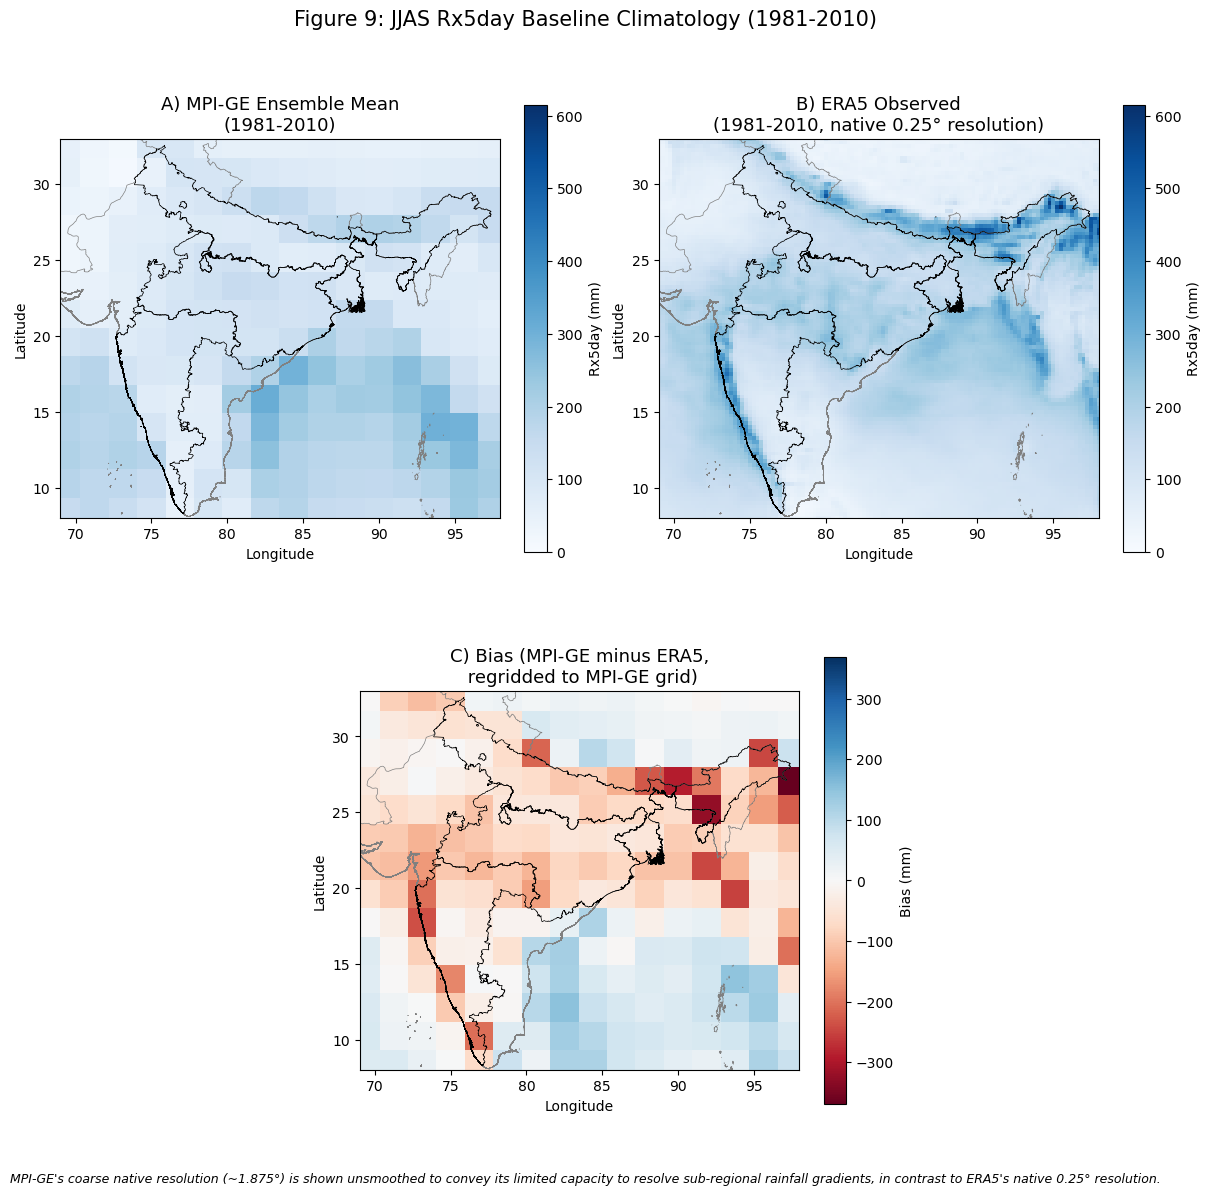

Figure 9 saved


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 14))
gs = gridspec.GridSpec(2, 4, height_ratios=[1, 1], hspace=0.05, wspace=0.6)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])

vmax_clim = max(float(mpi_climatology.max()), float(era5_climatology.max()))

# Tightened left bound to match MPI's actual leftmost cell edge (avoids unpainted sliver)
LON_VIEW = (69, 98)
LAT_VIEW = (8, 33)

india_outline = gdf_clean.dissolve().boundary

im1 = ax1.pcolormesh(mpi_climatology.lon, mpi_climatology.lat, mpi_climatology.values,
                      cmap='Blues', vmin=0, vmax=vmax_clim, shading='nearest')
ax1.set_title('A) MPI-GE Ensemble Mean\n(1981-2010)', fontsize=13)
india_outline.plot(ax=ax1, color='grey', linewidth=0.5, zorder=1)
gdf_regions.boundary.plot(ax=ax1, color='black', linewidth=0.5, zorder=2)
ax1.set_xlim(*LON_VIEW)
ax1.set_ylim(*LAT_VIEW)
plt.colorbar(im1, ax=ax1, label='Rx5day (mm)', fraction=0.046)

im2 = ax2.pcolormesh(era5_climatology.longitude, era5_climatology.latitude, era5_climatology.values,
                      cmap='Blues', vmin=0, vmax=vmax_clim, shading='auto')
ax2.set_title('B) ERA5 Observed\n(1981-2010, native 0.25° resolution)', fontsize=13)
india_outline.plot(ax=ax2, color='grey', linewidth=0.5, zorder=1)
gdf_regions.boundary.plot(ax=ax2, color='black', linewidth=0.5, zorder=2)
ax2.set_xlim(*LON_VIEW)
ax2.set_ylim(*LAT_VIEW)
plt.colorbar(im2, ax=ax2, label='Rx5day (mm)', fraction=0.046)

bias_abs_max = max(abs(float(bias.min())), abs(float(bias.max())))
im3 = ax3.pcolormesh(bias.lon, bias.lat, bias.values,
                      cmap='RdBu', vmin=-bias_abs_max, vmax=bias_abs_max, shading='nearest')
ax3.set_title('C) Bias (MPI-GE minus ERA5,\n regridded to MPI-GE grid)', fontsize=13)
india_outline.plot(ax=ax3, color='grey', linewidth=0.5, zorder=1)
gdf_regions.boundary.plot(ax=ax3, color='black', linewidth=0.5, zorder=2)
ax3.set_xlim(*LON_VIEW)
ax3.set_ylim(*LAT_VIEW)
plt.colorbar(im3, ax=ax3, label='Bias (mm)', fraction=0.046)

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')

fig.suptitle('Figure 9: JJAS Rx5day Baseline Climatology (1981-2010)', fontsize=15, y=0.92)


fig.canvas.draw()
pos3 = ax3.get_position()
fig.text(0.5, pos3.y0 - 0.08, caption, ha='center', fontsize=9, style='italic', wrap=True)

plt.savefig(OUTPUT_DIR + 'figure9_baseline_climatology_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved')

In [11]:
import pandas as pd
import regionmask

gdf_regions_indexed = gdf_regions.reset_index()
gdf_regions_indexed['region_id'] = gdf_regions_indexed.index

region_bias_records = []
for idx, row in gdf_regions_indexed.iterrows():
    region_name = row['region']
    single_region_gdf = gdf_regions_indexed.iloc[[idx]]
    mask = regionmask.mask_geopandas(single_region_gdf, bias.lon, bias.lat, numbers='region_id')
    region_bias_vals = bias.where(~mask.isnull())
    region_bias_records.append({
        'region': region_name,
        'mean_bias_mm': float(region_bias_vals.mean()),
        'rmse_mm': float(np.sqrt((region_bias_vals ** 2).mean()))
    })

region_bias_df = pd.DataFrame(region_bias_records)
print(region_bias_df)

domain_rmse = float(np.sqrt((bias ** 2).mean()))
print(f"Domain-wide RMSE: {domain_rmse:.1f} mm")

                region  mean_bias_mm     rmse_mm
0        Central_India    -75.984632   80.167312
1  Indo_Gangetic_Plain    -71.311870   84.651360
2            Northeast   -190.674677  215.407068
3        Western_Ghats    -76.251671  100.207917
Domain-wide RMSE: 90.0 mm


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 6: Extract MPI-GE Daily Climatology by Member</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Extracts the day-of-year climatology (1981-2010) for each of the 30 MPI-GE members individually, needed for the per-member spread shown in Figure 10.</p>
</div>

In [12]:
import xarray as xr
import numpy as np
import glob
import os

HIST_PATH = '/data/oacd/smiles/MPI/historical/pr_day/'
OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
MEMBERS = [f'r{i}i1p1f1' for i in range(1, 31)]
LAT_MIN, LAT_MAX = 8, 35
LON_MIN, LON_MAX = 68, 99
BASELINE_START, BASELINE_END = 1981, 2010

def extract_daily_baseline(member):
    files = sorted(glob.glob(os.path.join(HIST_PATH, f'*{member}*.nc')))
    ds = xr.open_mfdataset(files, combine='by_coords', chunks={'time': 365})
    pr = (ds['pr'] * 86400).sel(lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))
    pr_baseline = pr.sel(time=pr.time.dt.year.isin(range(BASELINE_START, BASELINE_END + 1)))
    # Day-of-year climatology (leap years: day 366 will have fewer samples, that's fine)
    daily_clim = pr_baseline.groupby('time.dayofyear').mean(dim='time')
    return daily_clim.compute()

member_results = []
for m in MEMBERS:
    print(f'Processing {m}...')
    member_results.append(extract_daily_baseline(m))

mpi_daily_ensemble = xr.concat(member_results, dim='member').mean(dim='member')
mpi_daily_ensemble.to_dataset(name='pr_daily_clim').to_netcdf(OUTPUT_DIR + 'mpi_daily_climatology_baseline.nc')
print('Saved MPI daily baseline climatology')

Processing r1i1p1f1...
Processing r2i1p1f1...
Processing r3i1p1f1...
Processing r4i1p1f1...
Processing r5i1p1f1...
Processing r6i1p1f1...
Processing r7i1p1f1...
Processing r8i1p1f1...
Processing r9i1p1f1...
Processing r10i1p1f1...
Processing r11i1p1f1...
Processing r12i1p1f1...
Processing r13i1p1f1...
Processing r14i1p1f1...
Processing r15i1p1f1...
Processing r16i1p1f1...
Processing r17i1p1f1...
Processing r18i1p1f1...
Processing r19i1p1f1...
Processing r20i1p1f1...
Processing r21i1p1f1...
Processing r22i1p1f1...
Processing r23i1p1f1...
Processing r24i1p1f1...
Processing r25i1p1f1...
Processing r26i1p1f1...
Processing r27i1p1f1...
Processing r28i1p1f1...
Processing r29i1p1f1...
Processing r30i1p1f1...
Saved MPI daily baseline climatology


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 7: Regional Seasonality Correlation (MPI-GE vs ERA5)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Area-averages both MPI-GE and ERA5's daily climatologies into each study region, standardizes both to a 0-1 range to compare timing independent of magnitude, and computes the Pearson correlation between them per region.</p>
</div>

In [13]:
import pandas as pd
from scipy.stats import pearsonr
import regionmask

era5_daily_all = xr.open_dataset(OUTPUT_DIR + 'era5_baseline_daily_allmonths.nc')['pr_daily']
era5_daily_clim = era5_daily_all.groupby('valid_time.dayofyear').mean(dim='valid_time')

frac_overlap_era5 = xr.open_dataset(OUTPUT_DIR + 'frac_overlap_era5.nc')['frac_overlap_era5']

mpi_daily_ensemble = xr.open_dataset(OUTPUT_DIR + 'mpi_daily_climatology_baseline.nc')['pr_daily_clim']
frac_overlap_mpi = xr.open_dataset(OUTPUT_DIR + 'frac_overlap_mpi.nc')['frac_overlap_mpi']

REGION_ORDER = ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']
REGION_COLORS = {
    'Central_India': 'steelblue', 'Indo_Gangetic_Plain': 'crimson',
    'Northeast': 'orchid', 'Western_Ghats': 'darkturquoise'
}

def standardize(da):
    return (da - da.min()) / (da.max() - da.min())

def regional_weighted_mean(data, frac_overlap, region, lat_dim, lon_dim):
    weights = frac_overlap.sel(region=region)
    weighted_sum = (data * weights).sum(dim=[lat_dim, lon_dim])
    return weighted_sum / weights.sum()

results = {}
for region in REGION_ORDER:
    era5_regional = regional_weighted_mean(era5_daily_clim, frac_overlap_era5, region, 'latitude', 'longitude')
    mpi_regional = regional_weighted_mean(mpi_daily_ensemble, frac_overlap_mpi, region, 'lat', 'lon')

    era5_std = standardize(era5_regional)
    mpi_std = standardize(mpi_regional)

    r, p = pearsonr(era5_std.values, mpi_std.values)
    results[region] = {'era5': era5_std, 'mpi': mpi_std, 'r': r, 'p': p}
    print(f"{region}: r={r:.3f}, p={p:.4f}")

Central_India: r=0.976, p=0.0000
Indo_Gangetic_Plain: r=0.966, p=0.0000
Northeast: r=0.939, p=0.0000
Western_Ghats: r=0.930, p=0.0000


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 8: Save Per-Member Daily Climatology</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Saves each MPI-GE member's individual daily climatology (not yet averaged across the ensemble) to disk, needed for the member-spread band shown in Figure 10.</p>
</div>

In [14]:
mpi_daily_by_member = xr.concat(member_results, dim='member')
mpi_daily_by_member = mpi_daily_by_member.assign_coords(member=MEMBERS)
mpi_daily_by_member.to_dataset(name='pr_daily_clim').to_netcdf(OUTPUT_DIR + 'mpi_daily_climatology_by_member.nc')
print('Saved, shape:', dict(mpi_daily_by_member.sizes))

Saved, shape: {'member': 30, 'dayofyear': 366, 'lat': 15, 'lon': 16}


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 9: Figure 10 - Standardized Daily Climatology with Member Spread</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Regional seasonality comparison, with the MPI-GE ensemble's 10th-90th percentile range shown across individual members, to show whether disagreement with ERA5 reflects a systematic bias or genuine internal-variability spread.</p>
</div>

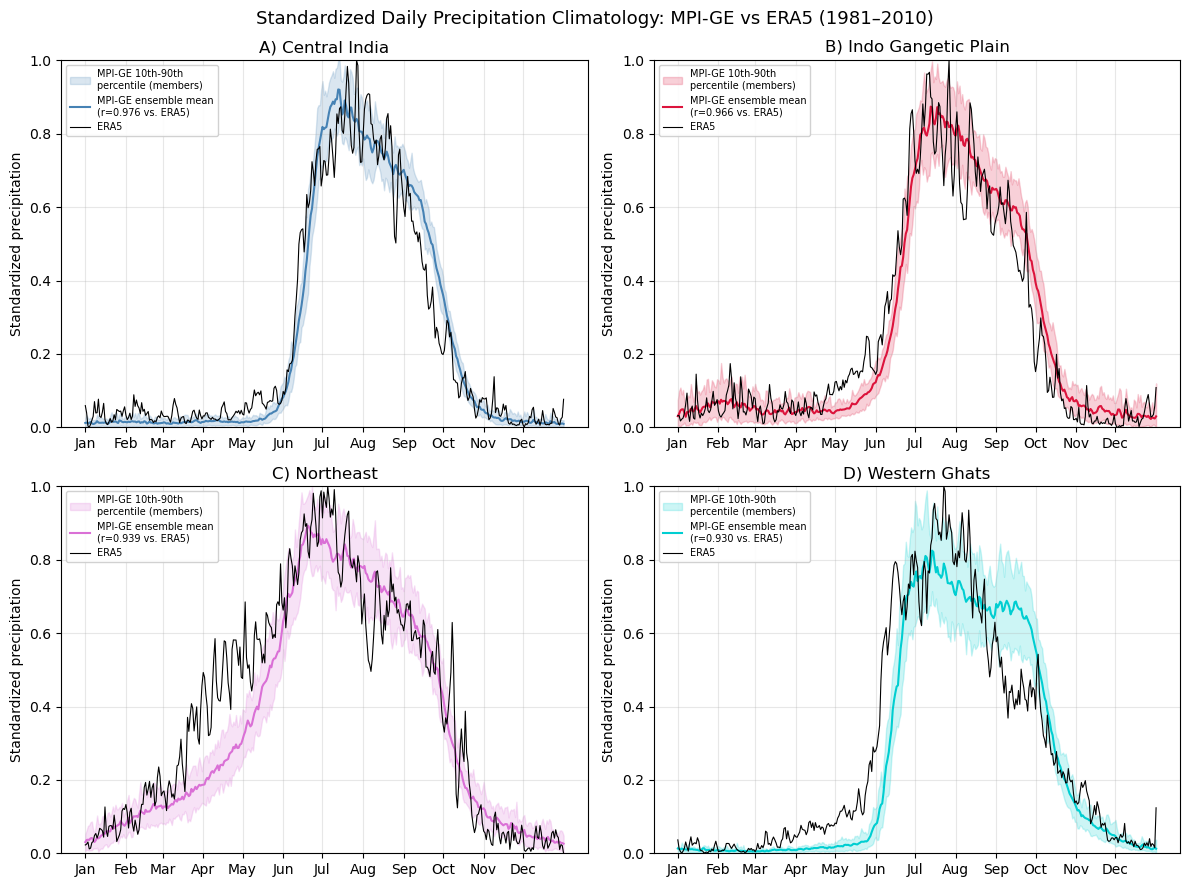

In [15]:
frac_overlap_mpi = xr.open_dataset(OUTPUT_DIR + 'frac_overlap_mpi.nc')['frac_overlap_mpi']

# Day-of-year values marking the start of each month (non-leap year, close enough for tick placement)
MONTH_STARTS = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
panel_letters = ['A)', 'B)', 'C)', 'D)']

for ax, region, letter in zip(axes.flat, REGION_ORDER, panel_letters):
    color = REGION_COLORS[region]
    era5_std = results[region]['era5']
    r = results[region]['r']

    member_curves = []
    for m in MEMBERS:
        member_regional = regional_weighted_mean(
            mpi_daily_by_member.sel(member=m), frac_overlap_mpi, region, 'lat', 'lon')
        member_curves.append(standardize(member_regional))

    member_stack = xr.concat(member_curves, dim='member')
    mpi_mean = member_stack.mean(dim='member')
    mpi_p10 = member_stack.quantile(0.10, dim='member')
    mpi_p90 = member_stack.quantile(0.90, dim='member')

    ax.fill_between(mpi_mean.dayofyear, mpi_p10, mpi_p90, color=color, alpha=0.2,
                     label='MPI-GE 10th-90th\npercentile (members)')
    ax.plot(mpi_mean.dayofyear, mpi_mean, color=color, linewidth=1.5,
            label=f'MPI-GE ensemble mean\n(r={r:.3f} vs. ERA5)')
    ax.plot(era5_std.dayofyear, era5_std, color='black', linewidth=0.8, label='ERA5', zorder=5)

    ax.set_title(f'{letter} {region.replace("_", " ")}')
    ax.set_xticks(MONTH_STARTS)
    ax.set_xticklabels(MONTH_LABELS)
    ax.set_ylabel('Standardized precipitation')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, loc='upper left', framealpha=0.9)
    ax.grid(alpha=0.3)

fig.suptitle('Standardized Daily Precipitation Climatology: MPI-GE vs ERA5 (1981–2010)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure_seasonality_check_band.png', dpi=150, bbox_inches='tight')
plt.show()